# Tutorial 8: Topological Data Analysis (Mapper)

**Duration:** 25-30 minutes

This tutorial covers the Mapper algorithm, a topological data analysis (TDA) technique for discovering the shape of data and identifying cell communities in tissue.

## Learning Objectives

By the end of this tutorial, you will be able to:
- Understand the Mapper algorithm conceptually
- Choose appropriate filter functions for spatial data
- Run Mapper analysis on tissue samples
- Interpret the resulting graph structure
- Identify hubs and communities in the Mapper graph

## Prerequisites

- Tutorials 1-7 completed
- Basic understanding of clustering concepts

## Biological Context

**What is Mapper?**

Mapper creates a simplified graph representation of high-dimensional data by:
1. Projecting data through a filter function
2. Covering the filter range with overlapping intervals
3. Clustering points within each interval
4. Connecting clusters that share points

**Applications in tissue biology:**
- Discovering cell communities without predefined labels
- Finding tissue gradients and transition zones
- Identifying hub cells connecting different regions
- Hypothesis generation for spatial organization

## Setup

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spatialtissuepy import SpatialTissueData
from spatialtissuepy.spatial import compute_neighborhoods
from spatialtissuepy.topology import (
    # Main classes
    SpatialMapper,
    MapperResult,
    spatial_mapper,
    # Filters
    density_filter,
    eccentricity_filter,
    entropy_filter,
    # Spatial filters
    distance_to_type_filter,
    radial_filter,
    spatial_density_filter,
    composite_filter,
    # Analysis
    node_summary_dataframe,
    find_hub_nodes,
    find_bridge_nodes,
    component_statistics,
    extract_mapper_features,
)
from spatialtissuepy.viz import (
    plot_spatial_scatter,
    plot_mapper_graph,
    plot_mapper_spatial,
    plot_filter_distribution,
    plot_node_composition,
)

np.random.seed(42)

### Create sample tissue

In [2]:
# Create tissue with spatial structure
# Central tumor cluster
tumor = np.random.normal(loc=[500, 500], scale=80, size=(200, 2))
tumor_types = ['Tumor'] * 200

# Immune cells infiltrating from one side
immune = np.random.normal(loc=[300, 500], scale=100, size=(100, 2))
immune_types = ['CD8_T_cell'] * 100

# Stromal cells on the other side
stromal = np.random.normal(loc=[700, 500], scale=80, size=(80, 2))
stromal_types = ['Stromal'] * 80

# Scattered macrophages
macro = np.random.uniform(100, 900, size=(60, 2))
macro_types = ['Macrophage'] * 60

coordinates = np.vstack([tumor, immune, stromal, macro])
cell_types = np.array(tumor_types + immune_types + stromal_types + macro_types)

tissue = SpatialTissueData(coordinates=coordinates, cell_types=cell_types)
print(tissue)

SpatialTissueData
  Cells: 440
  Dimensions: 2D
  Cell types: 4
  Bounds: x=[52.8, 905.9], y=[114.3, 890.1]


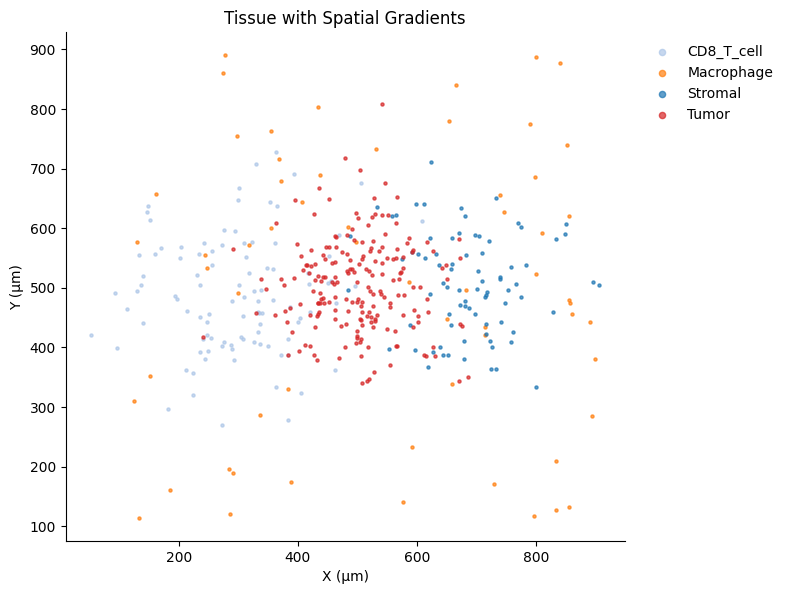

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))
plot_spatial_scatter(tissue, ax=ax)
ax.set_title('Tissue with Spatial Gradients')
plt.tight_layout()
plt.show()

## Section 1: Understanding Filter Functions

The filter function projects cells onto a 1D or 2D space. Different filters reveal different aspects of the data.

### Built-in Filters:

| Filter | Description | Use Case |
|--------|-------------|----------|
| `density` | Local cell density | Find dense vs sparse regions |
| `eccentricity` | Distance from centroid | Find central vs peripheral cells |
| `entropy` | Neighborhood diversity | Find homogeneous vs heterogeneous regions |
| `distance_to_type` | Distance to specific cell type | Find gradients from cell populations |
| `radial` | Distance from reference point | Radial organization |
| `x_coordinate` | Spatial x-position | Horizontal gradients |

In [25]:
dir(tissue)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_cell_types',
 '_coordinates',
 '_kdtree',
 '_markers',
 '_metadata',
 '_neighborhood_params',
 '_neighborhoods',
 '_sample_ids',
 'add_neighborhoods',
 'bounds',
 'cell_type_counts',
 'cell_types',
 'cell_types_unique',
 'coordinate_units',
 'coordinates',
 'extent',
 'from_csv',
 'from_dataframe',
 'get_cell',
 'get_cells_by_sample',
 'get_cells_by_type',
 'has_neighborhoods',
 'is_multisample',
 'iter_cells',
 'iter_samples',
 'kdtree',
 'marker_names',
 'markers',
 'metadata',
 'n_cell_types',
 'n_cells',
 'n_dims',
 'n_samples',
 'neighborhoods',
 'query_knn',
 'query_radius',
 'sample_ids',
 'sample_ids

In [32]:
compute_neighborhoods(tissue, radius=50)

[array([ 20,  25,  34,  38,  48,  49,  54,  64,  74,  75,  77,  93,  97,
        138, 139, 144, 147, 148, 152, 154, 158, 159, 167, 169, 171, 176,
        178, 182, 183, 188, 230]),
 array([ 32,  35,  70,  83, 105, 175, 180, 193, 304, 315, 353, 354]),
 array([  5,  12,  14,  21,  25,  28,  30,  38,  40,  46,  49,  51,  54,
         57,  64,  68,  84,  86, 108, 109, 116, 120, 123, 134, 138, 139,
        145, 152, 159, 166, 168, 171, 172, 174, 178, 183, 208, 217, 230,
        237, 323]),
 array([ 27,  59,  78, 101, 117, 124, 126, 163, 186, 310, 341, 342, 346,
        350, 356, 361, 376, 379]),
 array([  8,  12,  23,  26,  33,  40,  44,  52,  57,  66,  76,  80,  86,
         91,  92,  95,  98, 107, 109, 112, 114, 115, 119, 134, 137, 140,
        143, 146, 152, 155, 160, 170, 172, 181, 185, 192, 195, 208, 217,
        244, 247, 276, 382]),
 array([  2,  12,  14,  21,  28,  30,  38,  42,  46,  49,  51,  63,  64,
         68,  84,  85, 108, 109, 116, 120, 123, 130, 134, 139, 145, 150,
       

AttributeError: 'list' object has no attribute 'mean'

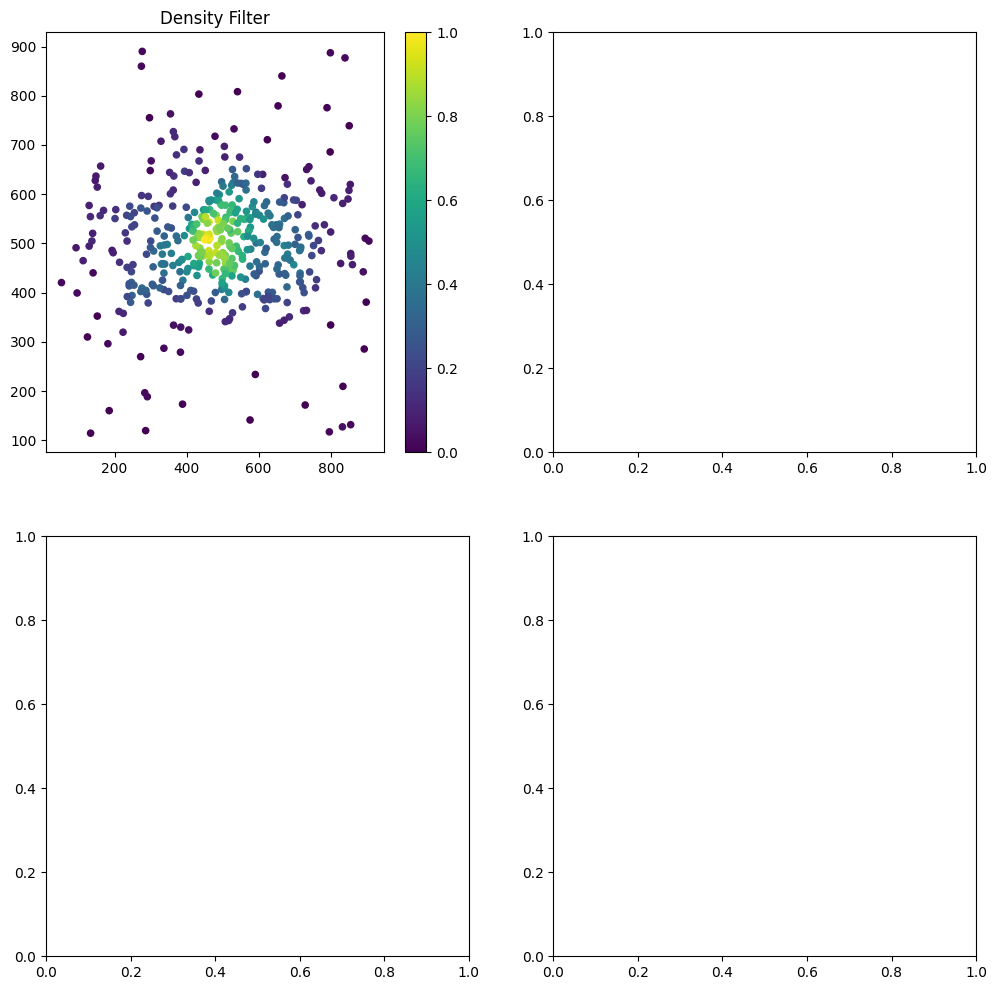

In [31]:
# Visualize different filter functions
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Density filter
density_filter = spatial_density_filter(radius=50.0)
density_vals = density_filter(
    coordinates=tissue.coordinates,
    neighborhoods=tissue._neighborhoods,
    data=tissue
)
scatter = axes[0, 0].scatter(tissue.coordinates[:, 0], tissue.coordinates[:, 1],
                              c=density_vals, cmap='viridis', s=20)
plt.colorbar(scatter, ax=axes[0, 0])
axes[0, 0].set_title('Density Filter')

# Eccentricity filter
ecc_filter = eccentricity_filter()
neighborhoods = compute_neighborhoods(tissue, radius=50)
eccentric_vals = ecc_filter(
    coordinates=tissue.coordinates,
    neighborhoods=neighborhoods,
    data=tissue
)
scatter = axes[0, 1].scatter(tissue.coordinates[:, 0], tissue.coordinates[:, 1],
                              c=eccentric_vals, cmap='viridis', s=20)
plt.colorbar(scatter, ax=axes[0, 1])
axes[0, 1].set_title('Eccentricity Filter (distance from center)')

# Distance to Tumor
dt_filter = distance_to_type_filter('Tumor')
dist_to_tumor = dt_filter(
    coordinates=tissue.coordinates,
    neighborhoods=tissue._neighborhoods,
    data=tissue
)
scatter = axes[1, 0].scatter(tissue.coordinates[:, 0], tissue.coordinates[:, 1],
                              c=dist_to_tumor, cmap='viridis', s=20)
plt.colorbar(scatter, ax=axes[1, 0])
axes[1, 0].set_title('Distance to Tumor')

# X-coordinate (spatial gradient)
x_vals = tissue.coordinates[:, 0]
scatter = axes[1, 1].scatter(tissue.coordinates[:, 0], tissue.coordinates[:, 1],
                              c=x_vals, cmap='viridis', s=20)
plt.colorbar(scatter, ax=axes[1, 1])
axes[1, 1].set_title('X-Coordinate Filter')

plt.tight_layout()
plt.show()

## Section 2: Running Mapper

### 2.1 Quick Mapper with Convenience Function

In [6]:
# Run Mapper with density filter
result = spatial_mapper(
    tissue,
    filter_fn='density',
    n_intervals=10,
    overlap=0.5,
    neighborhood_radius=50.0
)

print("Mapper Result:")
print(f"  Nodes: {result.n_nodes}")
print(f"  Edges: {result.n_edges}")
print(f"  Connected components: {result.n_components}")

Mapper Result:
  Nodes: 11
  Edges: 9
  Connected components: 2


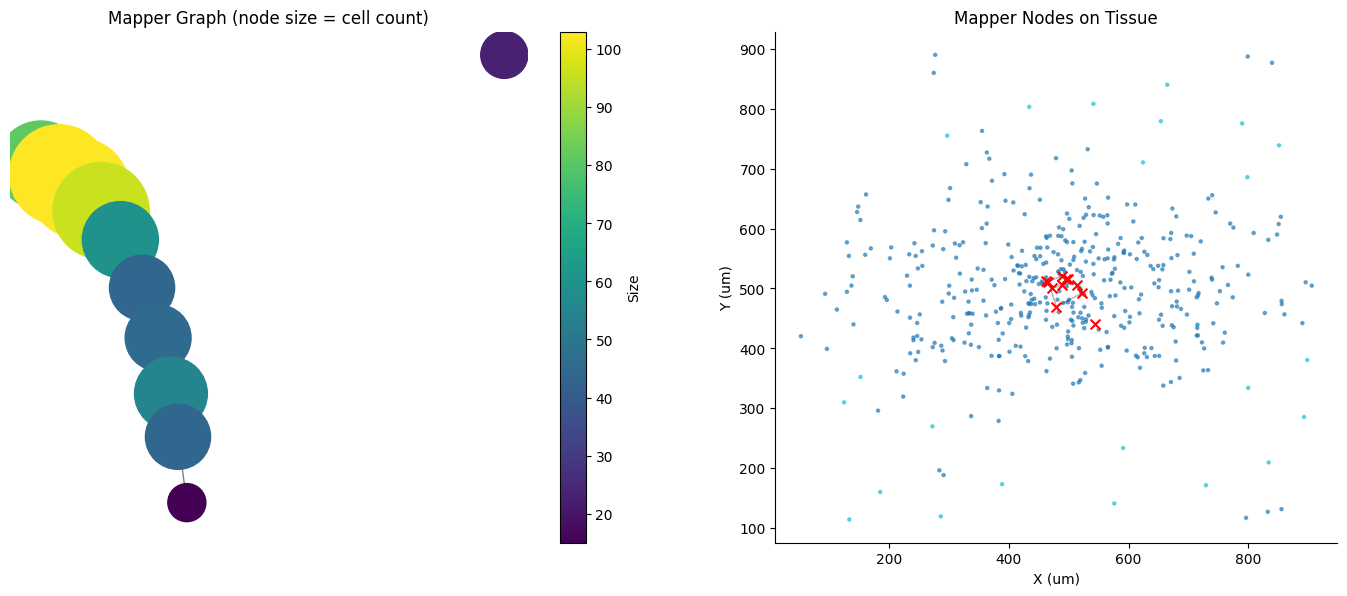

In [7]:
# Visualize the Mapper graph
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mapper graph
plot_mapper_graph(result, ax=axes[0], color_by='size')
axes[0].set_title('Mapper Graph (node size = cell count)')

# Spatial embedding
plot_mapper_spatial(result, tissue, ax=axes[1])
axes[1].set_title('Mapper Nodes on Tissue')

plt.tight_layout()
plt.show()

### 2.2 Using the Class Interface

In [11]:
# More control with SpatialMapper class
mapper = SpatialMapper(
    filter_fn=distance_to_type_filter('Tumor'),
    n_intervals=12,
    overlap=0.4,
    clustering='dbscan',  # or 'agglomerative', 'kmeans'
    clustering_params={'eps': 30, 'min_samples': 3}
)

result_tumor = mapper.fit(tissue, neighborhood_radius=50.0)

print(f"Mapper with distance-to-tumor filter:")
print(f"  Nodes: {result_tumor.n_nodes}")
print(f"  Edges: {result_tumor.n_edges}")

Mapper with distance-to-tumor filter:
  Nodes: 11
  Edges: 10


Mapper Result Summary:
  Total nodes: 22
  Total edges: 18
  Components: 4

Filter value range: [0.000, 1.000]
Found 55 cells with unusual neighborhood composition

High eccentricity nodes (>0.7): 7
    node_id  size  filter_mean  prop_Tumor  prop_CD8_T_cell  prop_Macrophage
15       15    18     0.725361    0.055556         0.888889         0.055556
16       16    12     0.747163         NaN              NaN         0.166667
17       17     5     0.716251         NaN              NaN         0.600000
18       18    25     0.850573    0.040000         0.800000         0.160000
19       19    18     0.875345         NaN              NaN         0.222222
20       20    13     1.000000         NaN         0.076923         0.769231
21       21    11     0.905502         NaN              NaN         0.272727


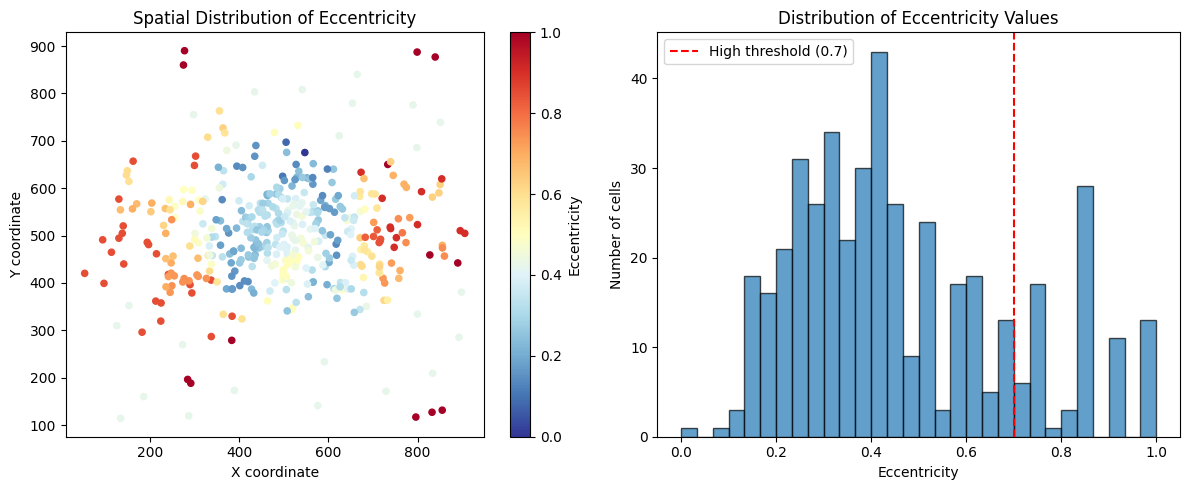

In [48]:
# Run Mapper
mapper = SpatialMapper(
    filter_fn=eccentricity_filter(normalize=True),
    n_intervals=10,
    overlap=0.5,
)
result = mapper.fit(tissue, neighborhood_radius=50.0)

# Get node statistics using the built-in function
node_df = node_summary_dataframe(result, tissue)

print(f"Mapper Result Summary:")
print(f"  Total nodes: {result.n_nodes}")
print(f"  Total edges: {result.n_edges}")
print(f"  Components: {result.n_components}")
print(f"\nFilter value range: [{result.filter_values.min():.3f}, {result.filter_values.max():.3f}]")

# Cells with high eccentricity (unusual neighborhoods)
unusual_cells = np.where(result.filter_values > 0.8)[0]
print(f"Found {len(unusual_cells)} cells with unusual neighborhood composition")

# Identify high-eccentricity nodes
high_ecc = node_df[node_df['filter_mean'] > 0.7]
print(f"\nHigh eccentricity nodes (>0.7): {len(high_ecc)}")
print(high_ecc[['node_id', 'size', 'filter_mean', 'prop_Tumor', 'prop_CD8_T_cell', 'prop_Macrophage']])

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Spatial plot colored by eccentricity
scatter = ax1.scatter(tissue.coordinates[:, 0], tissue.coordinates[:, 1], 
                      c=result.filter_values, cmap='RdYlBu_r', s=20)
plt.colorbar(scatter, ax=ax1, label='Eccentricity')
ax1.set_title('Spatial Distribution of Eccentricity')
ax1.set_xlabel('X coordinate')
ax1.set_ylabel('Y coordinate')

# Histogram of eccentricity values
ax2.hist(result.filter_values, bins=30, alpha=0.7, edgecolor='black')
ax2.axvline(0.7, color='red', linestyle='--', label='High threshold (0.7)')
ax2.set_xlabel('Eccentricity')
ax2.set_ylabel('Number of cells')
ax2.set_title('Distribution of Eccentricity Values')
ax2.legend()

plt.tight_layout()
plt.show()

## Section 3: Analyzing Mapper Results

### 3.1 Node Summary

In [13]:
# Get summary of all nodes
node_df = node_summary_dataframe(result, tissue)

print("Node Summary (first 10):")
node_df.head(10)

Node Summary (first 10):


,node_id,size,cover_element,cluster_label,filter_mean,filter_std,filter_min,filter_max,spatial_x,spatial_y,count_CD8_T_cell,prop_CD8_T_cell,count_Macrophage,prop_Macrophage,count_Stromal,prop_Stromal,count_Tumor,prop_Tumor
0,0,81,0,0,0.068861,0.032683,0.022222,0.111111,488.410184,521.072763,28,0.345679,27.0,0.333333,15.0,0.185185,11,0.135802
1,1,23,0,1,0.000000,0.000000,0.000000,0.000000,544.281656,441.400910,1,0.043478,19.0,0.826087,2.0,0.086957,1,0.043478
2,2,103,1,0,0.150809,0.048927,0.088889,0.222222,465.821106,511.240181,42,0.407767,13.0,0.126214,25.0,0.242718,23,0.223301
3,3,103,2,0,0.248759,0.043469,0.177778,0.311111,479.539371,469.674614,37,0.359223,6.0,0.058252,30.0,0.291262,30,0.291262
4,4,96,3,0,0.347222,0.044125,0.288889,0.422222,521.948822,492.200656,22,0.229167,5.0,0.052083,31.0,0.322917,38,0.395833
5,5,60,4,0,0.436667,0.043286,0.377778,0.511111,513.256279,505.419661,11,0.183333,3.0,0.050000,14.0,0.233333,32,0.533333
6,6,44,5,0,0.545455,0.042496,0.488889,0.622222,496.097826,516.455434,4,0.090909,1.0,0.022727,3.0,0.068182,36,0.818182
7,7,45,6,0,0.646914,0.047366,0.577778,0.711111,498.335829,515.697504,2,0.044444,1.0,0.022222,1.0,0.022222,41,0.911111
8,8,55,7,0,0.760404,0.046747,0.688889,0.822222,489.177451,505.925474,3,0.054545,1.0,0.018182,NaN,NaN,51,0.927273
9,9,44,8,0,0.827778,0.039391,0.777778,0.911111,472.557306,500.068544,4,0.090909,NaN,NaN,1.0,0.022727,39,0.886364


In [14]:
# Analyze node cell type compositions
print("\nNode Compositions:")
for node_id in range(min(5, result.n_nodes)):
    node = result.nodes[node_id]
    cell_indices = node.members
    types_in_node = tissue.cell_types[cell_indices]
    unique, counts = np.unique(types_in_node, return_counts=True)
    
    print(f"\nNode {node_id} ({len(cell_indices)} cells):")
    for ct, c in zip(unique, counts):
        print(f"  {ct}: {c} ({100*c/len(cell_indices):.0f}%)")


Node Compositions:

Node 0 (81 cells):
  CD8_T_cell: 28 (35%)
  Macrophage: 27 (33%)
  Stromal: 15 (19%)
  Tumor: 11 (14%)

Node 1 (23 cells):
  CD8_T_cell: 1 (4%)
  Macrophage: 19 (83%)
  Stromal: 2 (9%)
  Tumor: 1 (4%)

Node 2 (103 cells):
  CD8_T_cell: 42 (41%)
  Macrophage: 13 (13%)
  Stromal: 25 (24%)
  Tumor: 23 (22%)

Node 3 (103 cells):
  CD8_T_cell: 37 (36%)
  Macrophage: 6 (6%)
  Stromal: 30 (29%)
  Tumor: 30 (29%)

Node 4 (96 cells):
  CD8_T_cell: 22 (23%)
  Macrophage: 5 (5%)
  Stromal: 31 (32%)
  Tumor: 38 (40%)


### 3.2 Finding Hubs and Bridges

In [18]:
# Find hub nodes (highly connected)
hubs = find_hub_nodes(result, n_hubs=5)

print("Top 5 Hub Nodes (most edges):")
for node_id, degree in hubs:
    n_cells = len(result.nodes[node_id].members)
    print(f"  Node {node_id}: {degree} edges, {n_cells} cells")

Top 5 Hub Nodes (most edges):
  Node 2: 2 edges, 103 cells
  Node 3: 2 edges, 103 cells
  Node 4: 2 edges, 96 cells
  Node 5: 2 edges, 60 cells
  Node 6: 2 edges, 44 cells


In [19]:
# Find bridge nodes (connect different regions)
bridges = find_bridge_nodes(result)

if bridges:
    print(f"\nBridge Nodes (connect otherwise separate regions): {bridges}")
else:
    print("\nNo bridge nodes found (graph may be well-connected)")


Bridge Nodes (connect otherwise separate regions): [(5, 0.4444444444444445), (6, 0.4444444444444445), (4, 0.4), (7, 0.4), (3, 0.3111111111111111)]


### 3.3 Component Analysis

In [21]:
component_statistics?

Signature: component_statistics(result: "'MapperResult'") -> 'pd.DataFrame'
Docstring:
Compute statistics for each connected component.

Parameters
----------
result : MapperResult
    Mapper result.

Returns
-------
pd.DataFrame
    DataFrame with one row per component.
File:      ~/miniforge3/envs/spatialtissue-tutorials/lib/python3.10/site-packages/spatialtissuepy/topology/analysis.py
Type:      function

In [23]:
# Analyze connected components
comp_stats = component_statistics(result)

print("Connected Component Statistics:")
comp_stats

Connected Component Statistics:


,component_id,n_nodes,n_edges,n_cells,filter_mean,filter_std,count_CD8_T_cell,count_Macrophage,count_Stromal,count_Tumor
0,0,10,9,417,0.382734,0.26083,157,57,121,311
1,1,1,0,23,0.000000,0.00000,1,19,2,1


## Section 4: Different Filter Functions

### 4.1 Comparing Filter Choices

TypeError: eccentricity_filter() takes from 0 to 1 positional arguments but 3 were given

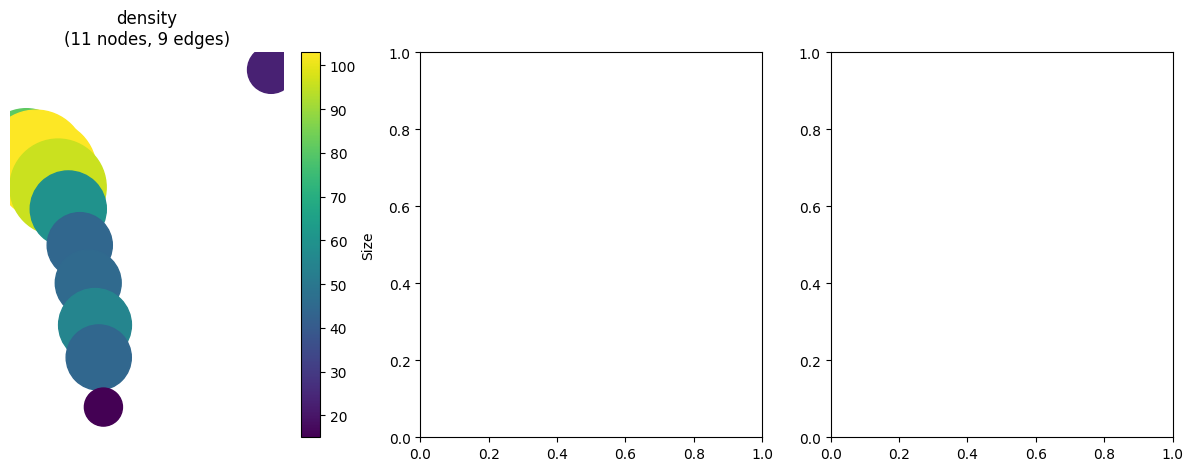

In [24]:
# Run Mapper with different filters
filters = [
    ('density', 'density'),
    ('eccentricity', eccentricity_filter),
    ('x_coordinate', lambda data: data.coordinates[:, 0]),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, filter_fn) in zip(axes, filters):
    result = spatial_mapper(
        tissue,
        filter_fn=filter_fn,
        n_intervals=10,
        overlap=0.5,
        neighborhood_radius=50.0
    )
    plot_mapper_graph(result, ax=ax, color_by='size')
    ax.set_title(f'{name}\n({result.n_nodes} nodes, {result.n_edges} edges)')

plt.tight_layout()
plt.show()

### 4.2 Composite Filters

In [ ]:
# Create composite filter (combination of multiple filters)
def my_composite_filter(data):
    density = spatial_density_filter(data, radius=50.0)
    x_coord = data.coordinates[:, 0]
    
    # Normalize both
    density_norm = (density - density.min()) / (density.max() - density.min())
    x_norm = (x_coord - x_coord.min()) / (x_coord.max() - x_coord.min())
    
    # Combine with weights
    return 0.5 * density_norm + 0.5 * x_norm

result_composite = spatial_mapper(
    tissue,
    filter_fn=my_composite_filter,
    n_intervals=10,
    overlap=0.5
)

print(f"Composite filter result: {result_composite.n_nodes} nodes, {result_composite.n_edges} edges")

## Section 5: Feature Extraction

In [ ]:
# Extract features from Mapper result
features = extract_mapper_features(result)

print("Mapper Features:")
for key, value in features.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

## Section 6: Parameter Sensitivity

### Key Parameters:
- **n_intervals:** Number of bins in the filter (more = finer resolution)
- **overlap:** Fraction of overlap between bins (higher = more connectivity)

In [ ]:
# Effect of n_intervals
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, n_int in zip(axes, [5, 10, 15, 20]):
    result = spatial_mapper(tissue, filter_fn='density', n_intervals=n_int, overlap=0.5)
    plot_mapper_graph(result, ax=ax, color_by='size')
    ax.set_title(f'n_intervals={n_int}\n({result.n_nodes} nodes)')

plt.tight_layout()
plt.show()

In [ ]:
# Effect of overlap
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, overlap in zip(axes, [0.2, 0.4, 0.6, 0.8]):
    result = spatial_mapper(tissue, filter_fn='density', n_intervals=10, overlap=overlap)
    plot_mapper_graph(result, ax=ax, color_by='size')
    ax.set_title(f'overlap={overlap}\n({result.n_edges} edges)')

plt.tight_layout()
plt.show()

print("\nLower overlap = fewer edges (more disconnected)")
print("Higher overlap = more edges (more connected)")

## Exercise: Discover Tissue Communities

1. **Filter selection:** Try `distance_to_type_filter('CD8_T_cell')` to find gradients from immune cells. How does the Mapper graph change?

2. **Community labeling:** For each connected component in your best Mapper result, determine the dominant cell type and give it a biological label.

3. **Hub cell analysis:** Extract the actual cells in hub nodes. What are their cell types? Where are they located?

In [ ]:
# Your code here


## Summary

In this tutorial, you learned:

- **Mapper algorithm:** How it creates graph representations of data shape
- **Filter functions:** Different projections reveal different aspects of tissue organization
- **Result interpretation:** Nodes represent cell communities, edges represent overlap
- **Hub/bridge analysis:** Identifying structurally important cells
- **Parameter tuning:** Effects of n_intervals and overlap

**Key insights:**
- Mapper provides hypothesis-free discovery of tissue structure
- Filter choice determines what aspects of organization are revealed
- Hubs and bridges identify transition zones between regions
- Features extracted from Mapper can be used for sample comparison

## Next Steps

- **Tutorial 9: Visualization** - Publication-quality plotting
- **Tutorial 10: Multi-Sample** - Comparing samples using Mapper features